# The Stock Keep Class

The Stock Keep module offer a way to complete all the typical steps:

train model -> forecast -> optimise -> validate

in one class call. To demonstrate we first create some data

In [9]:
from pathlib import Path
import pandas as pd

data_dir = Path('../data/demand-forecasting')
file_path = data_dir / 'train.csv'

df_train = pd.read_csv(file_path)

df_train.head()

df_train = df_train.groupby(["date", "item"]).sum().reset_index().drop(columns="store")

df_a = df_train[df_train["item"]==1]
df_b = df_train[df_train["item"]==2]

df_history = pd.concat([df_a, df_b], ignore_index=True)

In [ ]:
import pandas as pd
import numpy as np
from optistock.stockkeep import StockKeep
from optistock.solvers import StochasticMonteCarloSolver, MultiItemConstrainedSolver
from optistock.distributions.yield_distributions import BetaYield
from pathlib import Path
import pandas as pd

data_dir = Path('../data/demand-forecasting')
file_path = data_dir / 'train.csv'

df_train = pd.read_csv(file_path)

df_train.head()

df_train = df_train.groupby(["date", "item"]).sum().reset_index().drop(columns="store")

# Convert "fake" item history to our items
df_a = df_train[df_train["item"]==1]
df_a.loc[df_train["item"] == 1, "item"] = "Tablet Air"
df_b = df_train[df_train["item"]==2]
df_b.loc[df_train["item"] == 2, "item"] = "Laptop Pro"
df_history = pd.concat([df_a, df_b], ignore_index=True)

# Define items as a list of dictionaries
item_list = [
    {
        "name": "Tablet Air",          
        "cost_price": 300,
        "selling_price": 600,
        "salvage_value": 100,
        "storage": 2.0,                
    },
    {
        "name": "Laptop Pro",
        "cost_price": 800,
        "selling_price": 1200,
        "salvage_value": 400,
        "storage": 5.0,
    }
]

# Create the single DataFrame
df_items = pd.DataFrame(item_list)

C:\Users\bouwe\AppData\Local\Temp\ipykernel_6100\1356556107.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Tablet Air' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_a.loc[df_train["item"] == 1, "item"] = "Tablet Air"
C:\Users\bouwe\AppData\Local\Temp\ipykernel_6100\1356556107.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Laptop Pro' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_b.loc[df_train["item"] == 2, "item"] = "Laptop Pro"


## The Class Call

we can define the problem parameters and run the workflow from start to finish.

In [21]:
yield_map = {
    "Tablet Air": BetaYield(9, 1)
}
mgr = StockKeep(df_history, df_items, yield_profiles = yield_map)

results = mgr.run_simulation(
    forecast_days=14, 
    solver_class=StochasticMonteCarloSolver,
    solver_params={"limits": {"storage" : 1000}}
)

# View Performance
print(f"Total Portfolio Profit: {results['metrics']['portfolio_total_profit']}")
for item, data in results['metrics'].items():
    if item != "portfolio_total_profit":
        print(f"{item}: Allocated {results['allocation'][item]} units | Service Level: {data['service_level']}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.
Sampling: [y]


Output()

Sampling: [y]


Output()

Total Portfolio Profit: 149700.0
Tablet Air: Allocated 499 units | Service Level: 0.193
Laptop Pro: Allocated 0 units | Service Level: 0.0


## View results

- holdout (suggested vs mean or other method)
- actual future pred

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Forecast Validation: Laptop Pro'}>)

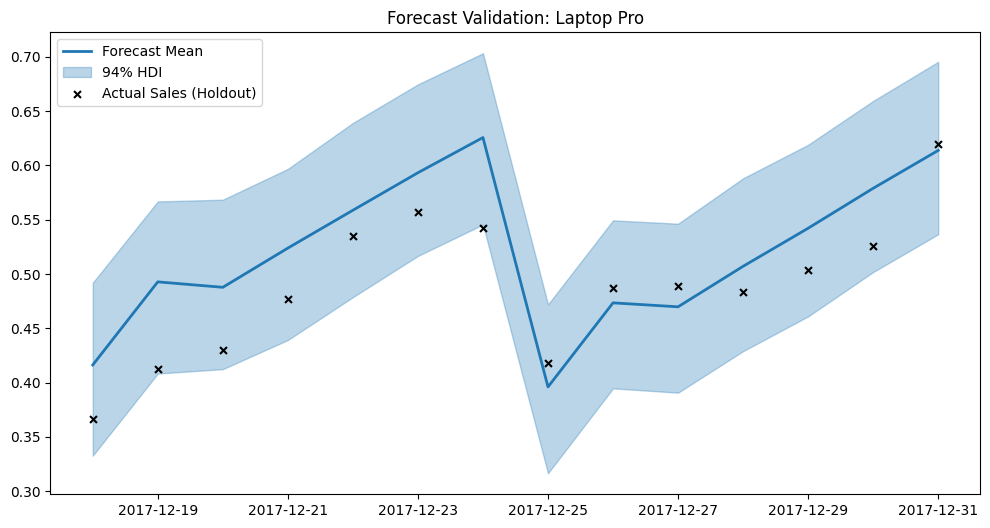

In [19]:
mgr.plot_forecast("Laptop Pro")

In [20]:
results

{'allocation': {'Tablet Air': np.int64(49), 'Laptop Pro': np.int64(0)},
 'metrics': {'Tablet Air': {'profit': np.int64(14700),
   'service_level': np.float64(0.019),
   'stockout': np.True_,
   'leftover_units': 0},
  'Laptop Pro': {'profit': np.int64(0),
   'service_level': np.float64(0.0),
   'stockout': np.True_,
   'leftover_units': 0},
  'portfolio_total_profit': np.float64(14700.0)},
 'period': (Timestamp('2017-12-18 00:00:00'),
  Timestamp('2017-12-31 00:00:00'))}